In [ ]:
%matplotlib inline

In [ ]:
import math

import numpy as np
import sympy as sp
from IPython.display import Image

## Function Vectorization

Key Ideas

* Most standard functions are written to work with single values. In software engineering, if we want them to process many values, we usually add a loop inside the function.
* In machine learning, functions often appear to operate on a single value, but in practice they are applied to entire vectors or matrices of values at once.

Two examples to showcase the ideas above.

In [87]:
# Most NumPy functions (such as `np.exp`) are already vectorized, meaning they automatically work with arrays without requiring loops.

def sigmoid(z):
    return 1. / (1. + np.exp(-z))

In [88]:
# We can convert a scalar function so it works on arrays using `np.vectorize()`. Rarely needed in practice.

def square(x):
    return x**2

square = np.vectorize(square)
arr = np.array([1, 2, 3, 4])
square(arr)

array([ 1,  4,  9, 16])

Most textbook equations follow the same pattern—you don’t immediately know what kind of object a symbol represents or what shape it has. I’ve found it helpful to write down the shapes (e.g. by using draw.io). Example below is from Géron [3].

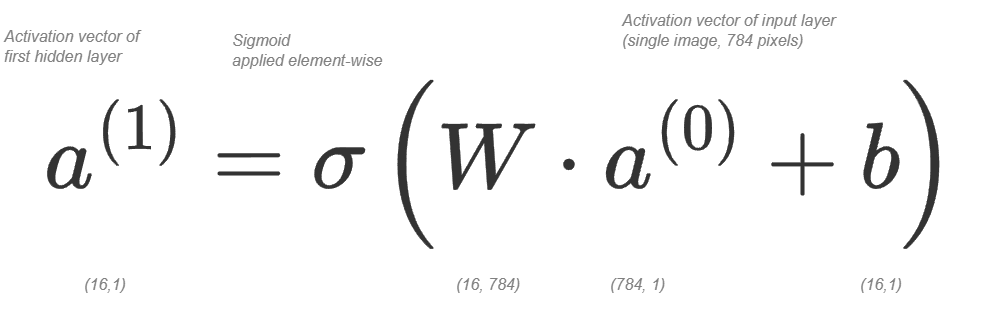

In [89]:
Image(filename='images/02.png', width=800)

## Neurons Types

Neural network explanations often mention several foundational neuron models: TLU, Perceptron, and Adaline. I struggled to understand the difference between them.

All of them are single‑unit (or single‑layer) abstractions inspired by biological neurons, computing a weighted sum of inputs.

**Historical progression**

- The TLU (1943) introduced the basic idea but had no learning — weights were set by hand.
- The Perceptron (1958) added an automatic learning rule.
- Adaline (1960) refined it so that weight updates use the continuous linear output rather than the thresholded prediction.

**Output behavior**

- TLU: binary output
- Perceptron: binary output
- Adaline: uses a continuous output during training for weight updates, but still applies a threshold to produce a binary prediction

**Learning characteristics**

- TLU: no learning mechanism — weights were manually configured
- Perceptron: updates weights based on binary classification errors
- Adaline: updates weights based on continuous error values, enabling smoother and more efficient optimization

**Error handling**

The Perceptron updates only when it misclassifies, whereas Adaline measures how far off the continuous prediction is, allowing more precise weight adjustments.

## Vectors as Matrices

In ML, vectors are often treated as matrices so that linear algebra operations like matrix multiplication work consistently. Although mathematically a vector of size n can be written simply as `(n,)`, many ML implementations treat it as a column matrix of shape `(n,1)`.

In [90]:
W = np.arange(1, 10).reshape((3,3))
x = np.array([2, -1, 4])

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([ 2, -1,  4]),
 array([12, 27, 42]))

In [91]:
W = np.arange(1, 10).reshape((3,3))
x = np.array([2, -1, 4]).reshape(-1, 1)

W, x, W @ x

(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([[ 2],
        [-1],
        [ 4]]),
 array([[12],
        [27],
        [42]]))

## Calculate Neuron Activation

Calculating the activation of a layer based on the preceding layer can be confusing, especially since different authors use different conventions for matrix orientation.

To clear this up, I have compared the equations used by Géron [1] and 3Blue1Brown [3]. To make these abstract formulas more concrete, I used a dataset - the classical [MNIST](https://en.wikipedia.org/wiki/MNIST_database). First equation to calculate the hidden layer activations is Géron's [1] (it contains all training examples), next comes 3Blue1Brown [3] and is for a single instance. At a glance:
- Géron [1]: Uses a vectorized approach designed for the entire training set at once. Mini-batch can also be used.
- 3Blue1Brown [3]: Focuses on the intuition of a single training instance.

Pay close attention to the symbols and the order of multiplication. The comments on the diagrams below provide a deeper dive into how these two notations differ from one another.

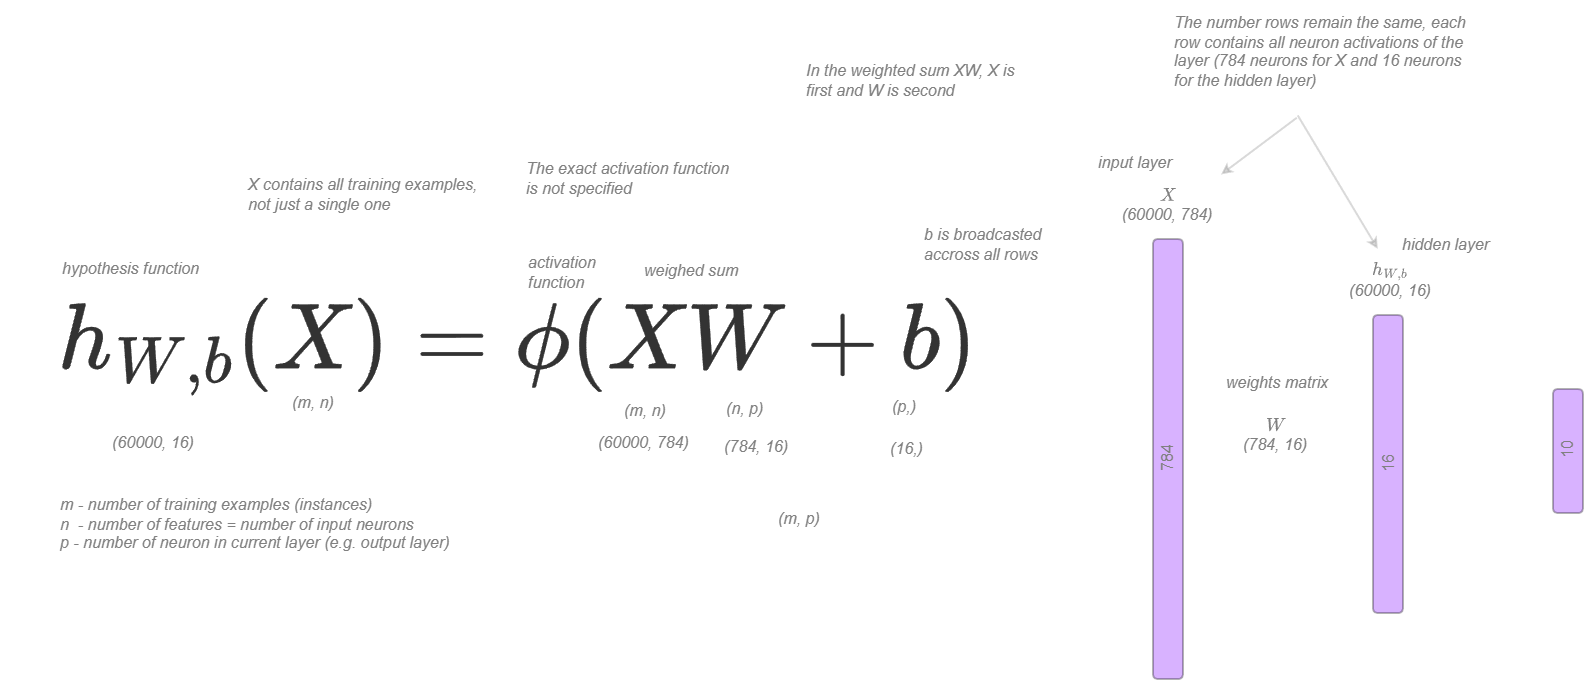

In [92]:
Image(filename='images/01.png', width=1200)

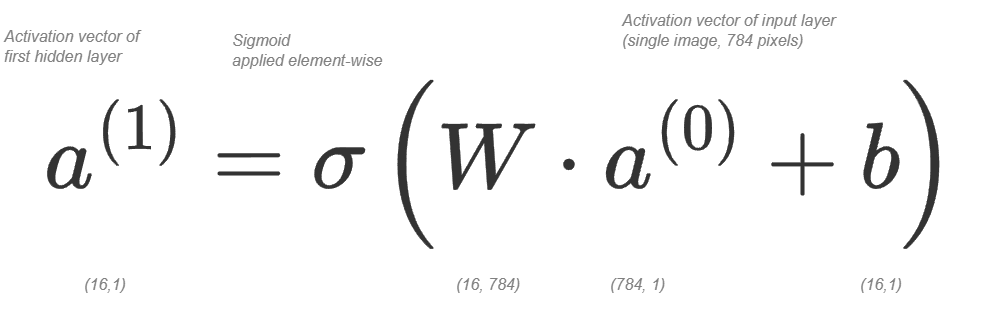

In [93]:
Image(filename='images/02.png', width=800)

## Compute Derivatives

How do computers compute derivatives, which are needed to update neural network parameters?

Generally, there are four main approaches:

1. Manual: Deriving the derivative formula manually using calculus rules
2. Numerical: Approximating the derivative using the difference formula
3. Symbolic: Applying symbolic differentiation rules automatically, similar to manual calculus but performed by software
4. AutoDiff: Using Automatic Differentiation, with backpropagation being the version used in neural networks

Let's see an example:

$$y = \ln(x_1) + x_1 x_2 - \sin(x_2)$$

and we want $$\frac{\partial{y}}{\partial{x_1}} \text{ at } x_1 = 2, x_2 = 5$$

True derivative at those values is:
$$\frac{\partial{y}}{\partial{x_1}} = \frac{1}{x_1} + x_2 = \frac{1}{2} + 5 = 5.5$$

**Manual**

Differentiate term by term. We then use the derivative formula DIRECTLY in the code.

$$\frac{\partial}{\partial x_1}\bigl[\ln x_1\bigr] = \frac{1}{x_1}, \quad \frac{\partial}{\partial x_1}\bigl[x_1 x_2\bigr] = x_2, \quad \frac{\partial}{\partial x_1}\bigl[\sin x_2\bigr] = 0$$

$$\boxed{\frac{\partial y}{\partial x_1} = \frac{1}{x_1} + x_2}$$

In [94]:
def manual(x1, x2):
    return 1/x1 + x2

manual(2.0, 5.0)

5.5

**Numerical**

$$\frac{\partial y}{\partial x_1} \approx \frac{f(x_1 + h,\ x_2) - f(x_1,\ x_2)}{h}$$

In [95]:
def f(x1, x2):
    return np.log(x1) + x1*x2 - np.sin(x2)

def numerical(x1, x2, h=1e-5):
    return (f(x1+h, x2) - f(x1, x2)) / h

numerical(2.0, 5.0)

np.float64(5.4999987499471095)

**Symbolic**

Manipulates the expression algebraically and returns an exact formula.

In [96]:
x1, x2 = sp.symbols('x1 x2')
f = sp.ln(x1) + x1*x2 - sp.sin(x2)

df = sp.diff(f, x1)
print(df)
print(df.subs({x1: 2, x2: 5}))

x2 + 1/x1
11/2


**AutoDiff**

All sources provide some explanation of backpropagation. I found

1. Create the computation graph — break the expression into primitive operations, each node is one operation
2. Assign intermediate variables (v1, v2, ...) one per node in the forward pass
3. Solve local derivatives by hand — for each node, derive the simple local gradient (e.g. d(ln x)/dx = 1/x)
4. Seed the backward pass — set dy/dy = 1
5. Walk the graph in reverse — multiply local gradients by the incoming gradient (chain rule), propagating back toward the inputs
6. Accumulate at inputs — if a variable (like x1) feeds into multiple nodes, sum all gradient contributions

Key gotchas:
- the derivatives must be propagated at each step, to
- the simple local derivatives are calulated symbolically and added to the code

```mermaid
graph LR
    x1(["x₁"])
    x2(["x₂"])

    v1["v₁ = ln(x₁)"]
    v2["v₂ = x₁ · x₂"]
    v3["v₃ = v₁ + v₂"]
    v4["v₄ = sin(x₂)"]
    y(["y = v₃ − v₄"])

    x1 --> v1
    x1 --> v2
    x2 --> v2
    x2 --> v4
    v1 --> v3
    v2 --> v3
    v3 --> y
    v4 --> y
```

In [97]:
def backward(x1, x2):
    # Forward pass
    v1 = math.log(x1)
    v2 = x1 * x2
    v3 = v1 + v2
    v4 = math.sin(x2)
    y  = v3 - v4

    # Backward pass
    d_y__d_y  = 1.0

    # y = v3 - v4
    d_y__d_v3 = d_y__d_y * 1.0
    d_y__d_v4 = d_y__d_y * -1.0

    # v3 = v1 + v2
    d_y__d_v1 = d_y__d_v3 * 1.0
    d_y__d_v2 = d_y__d_v3 * 1.0

    # v2 = x1 * x2,  v1 = ln(x1)
    d_y__d_x1 = (d_y__d_v1 * (1/x1)) + (d_y__d_v2 * x2)

    return d_y__d_x1


x1, x2 = 2.0, 5.0
dy_dx1 = backward(x1, x2)

print(f"dy/dx1 (autodiff) = {dy_dx1:.6f}")
print(f"dy/dx1 (analytic) = {1/x1 + x2:.6f}")

dy/dx1 (autodiff) = 5.500000
dy/dx1 (analytic) = 5.500000


I also found it quite useful to debug the code from [2] Raschka; it is [publicly avalable at GitHub [5]](https://github.com/rasbt/machine-learning-book/blob/main/ch11/neuralnet.py). I paste a snippet, the complete drawio diagram is available in the project files.

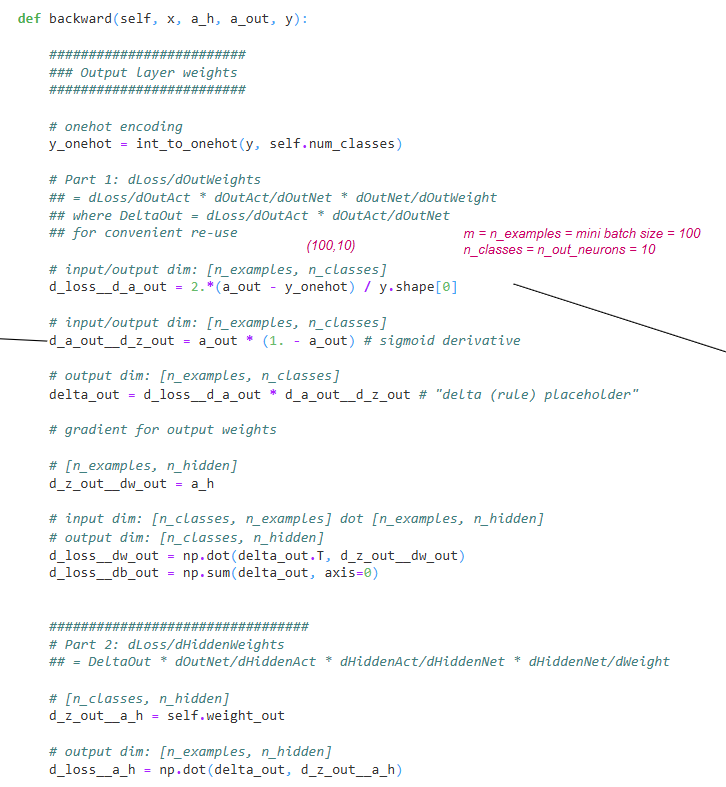

In [98]:
Image(filename='images/03.png', width=800)

Another AI-generated good short explanation of backprop.


Let’s look at a chain of operations: $a \to b \to c \to L$.

Forward Mode (Finding $\frac{\partial L}{\partial a}$)

1. How does $b$ change with $a$? $\to \frac{\partial b}{\partial a}$
2. How does $c$ change with $a$? $\to \frac{\partial c}{\partial b} \cdot \frac{\partial b}{\partial a}$
3. How does $L$ change with $a$? $\to \frac{\partial L}{\partial c} \cdot \frac{\partial c}{\partial b} \cdot \frac{\partial b}{\partial a}$

Repeat this entire sequence for every single input weight.

Reverse Mode (Backprop)

1. Start at the end: $\frac{\partial L}{\partial L} = 1$.
2. Move back: $\frac{\partial L}{\partial c} = 1 \cdot \frac{\partial L}{\partial c}$ (Save this value!)
3. Move back: $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial c} \cdot \frac{\partial c}{\partial b}$ (Use the saved value!)
4. Move back: $\frac{\partial L}{\partial a} = \frac{\partial L}{\partial b} \cdot \frac{\partial b}{\partial a}$ (Use the saved value!)

In one trip, you’ve calculated the gradient for $a, b,$ and $c$.


Finally, a brief summary of all four methods:
- Manual: 5.5 — exact, done by hand
- Numerical: 5.49999… — approximate, one call per parameter
- Symbolic: 11/2 = 5.5 — exact, but expression size explodes with depth
- AutoDiff: 5.5 — exact, all gradients in one backward pass